# Phase 6 — Baseline Models

**เป้าหมาย:** สร้างโมเดลพื้นฐาน 3 แบบที่ไม่ต้องเทรน (ไม่มีพารามิเตอร์ให้ fit) เพื่อใช้เป็น**เกณฑ์ขั้นต่ำ**ที่โมเดล ML ใน Phase 7 ต้องเอาชนะให้ได้ ถ้าโมเดลซับซ้อนสู้โมเดลพื้นฐานพวกนี้ไม่ได้ แปลว่าความซับซ้อนนั้นไม่คุ้มค่า

**โมเดลพื้นฐาน 3 แบบ** (นิยามใน `src/models/baseline.py`):
1. **Naive** — พยากรณ์สัปดาห์หน้า = ยอดขายสัปดาห์นี้ (persistence)
2. **Seasonal naive** — พยากรณ์สัปดาห์หน้า = ยอดขายสัปดาห์เดียวกันของปีที่แล้ว (52 สัปดาห์ก่อน)
3. **Moving average (4 สัปดาห์)** — พยากรณ์สัปดาห์หน้า = ค่าเฉลี่ยยอดขาย 4 สัปดาห์ล่าสุด (รวมสัปดาห์ปัจจุบัน)

ประเมินผลด้วย **walk-forward CV folds จาก Phase 5** (`src/splits/walk_forward.py`) เพื่อให้เทียบกับโมเดล ML ใน Phase 7 ได้แบบ apples-to-apples บน val weeks ชุดเดียวกัน


In [ ]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from splits.walk_forward import WalkForwardSplitter
from models.baseline import add_baseline_predictions
from models.metrics import score_all

pd.set_option('display.width', 160)

df = pd.read_csv('../data/processed/weekly_features.csv', parse_dates=['week'])
print('shape:', df.shape)


shape: (31027, 40)


## 1. สร้าง Walk-forward Folds และคำนวณ Baseline Predictions


In [ ]:
splitter = WalkForwardSplitter(initial_train_end='2023-09-30', val_fold_weeks=8, final_test_weeks=10)
folds, final_test_weeks = splitter.get_folds(df)

print(f'จำนวน CV folds: {len(folds)}')
print(f'final holdout: {len(final_test_weeks)} สัปดาห์ ({final_test_weeks.min()} - {final_test_weeks.max()})')

dfb = add_baseline_predictions(df)
print()
print('coverage (สัดส่วนแถวที่พยากรณ์ได้):')
for col in ['pred_naive', 'pred_seasonal_naive', 'pred_moving_avg_4']:
    print(f'  {col}: {dfb[col].notna().mean():.1%}')


จำนวน CV folds: 7
final holdout: 10 สัปดาห์ (2024-10-21T00:00:00.000000 - 2024-12-23T00:00:00.000000)



coverage (สัดส่วนแถวที่พยากรณ์ได้):
  pred_naive: 100.0%
  pred_seasonal_naive: 54.7%
  pred_moving_avg_4: 97.4%


**หมายเหตุ:** `pred_seasonal_naive` คำนวณได้แค่ ~55% ของแถวทั้งหมด เพราะต้องมีประวัติย้อนหลัง 52 สัปดาห์ ซึ่ง SKU ที่เปิดตัวหลัง ก.พ. 2023 ยังไม่มีประวัติยาวขนาดนั้น (สอดคล้องกับ unbalanced panel ที่เจอใน Phase 2) — จะประเมินเฉพาะแถวที่คำนวณได้เท่านั้น ไม่ได้ทำให้ตัวเลข WAPE เทียบกับโมเดลอื่นไม่แฟร์ เพราะเป็นข้อจำกัดของตัว baseline นี้เอง ไม่ใช่ของข้อมูล


## 2. ประเมินผลบน CV Folds และ Final Holdout


In [ ]:
pred_cols = {
    'Naive': 'pred_naive',
    'Seasonal Naive': 'pred_seasonal_naive',
    'Moving Avg (4w)': 'pred_moving_avg_4',
}

# หมายเหตุ: ไม่คำนวณ/โชว์ผลบน final_test_weeks ที่นี่ — final holdout (10 สัปดาห์สุดท้าย)
# ถูกประกาศไว้ตั้งแต่ Phase 5 ว่าจะไม่แตะจนกว่าจะถึง Phase 13 เพื่อรักษาความบริสุทธิ์ของ
# ชุดทดสอบสุดท้ายให้ตรวจสอบได้ (แม้ baseline พวกนี้จะไม่มีพารามิเตอร์ให้ fit ก็ตาม)
rows = []
for name, col in pred_cols.items():
    fold_scores = []
    for f in folds:
        val = dfb[dfb.week.isin(f.val_weeks)].dropna(subset=[col, 'target_next_week'])
        if len(val) == 0:
            continue
        fold_scores.append(score_all(val.target_next_week.values, val[col].values))
    avg = {k: np.mean([s[k] for s in fold_scores]) for k in fold_scores[0]}
    rows.append({'model': name, 'split': 'CV avg (7 folds)', **avg})

baseline_scoreboard = pd.DataFrame(rows)
baseline_scoreboard.round(3)


,model,split,MAE,RMSE,WAPE,SMAPE
0,Naive,CV avg (7 folds),34.225,43.847,0.304,0.307
1,Seasonal Naive,CV avg (7 folds),39.935,51.328,0.356,0.338
2,Moving Avg (4w),CV avg (7 folds),27.348,35.134,0.243,0.246


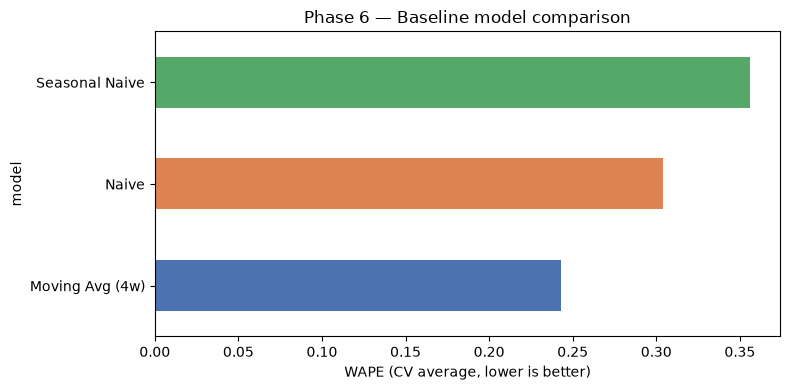

In [ ]:
cv_scores = baseline_scoreboard[baseline_scoreboard.split == 'CV avg (7 folds)'].set_index('model')

fig, ax = plt.subplots(figsize=(8, 4))
cv_scores['WAPE'].sort_values().plot(kind='barh', ax=ax, color=['#4C72B0', '#DD8452', '#55A868'])
ax.set_xlabel('WAPE (CV average, lower is better)')
ax.set_title('Phase 6 — Baseline model comparison')
plt.tight_layout()
plt.savefig('../reports/figures/phase6_baseline_scoreboard.png', dpi=120)
plt.show()


## 3. สรุปผล Phase 6

**ผลลัพธ์ (CV average WAPE):** Moving Average (4 สัปดาห์) ให้ผลดีที่สุดในบรรดา baseline ทั้ง 3 แบบ ตามด้วย Naive และ Seasonal Naive ตามลำดับ — สมเหตุสมผลเพราะยอดขายรายสัปดาห์มี noise สูง การเฉลี่ยหลายสัปดาห์ช่วยลด noise ได้ดีกว่าการใช้ค่าเดียว (naive) หรือค่าปีที่แล้ว (seasonal naive ซึ่งยิ่งมี coverage ต่ำและมี noise สะสมข้ามปีด้วย)

**ค่านี้คือเกณฑ์ขั้นต่ำ** ที่ LightGBM และโมเดลสถิติใน **Phase 7** ต้องทำได้ดีกว่า (WAPE ต่ำกว่า) ถึงจะถือว่าคุ้มค่ากับความซับซ้อนที่เพิ่มขึ้น
